# Data Leakage Impact Study — Machine Learning Project

This project investigates how improper data handling can lead to misleading machine learning model performance.

The workflow includes:

• Proper data splitting and preprocessing
• Building a baseline machine learning model
• Creating intentional data leakage scenarios
• Comparing model performance (Accuracy, Precision, Recall, F1-score)
• Analyzing how leakage inflates results



## Data Loading and Import Statements

This step connects Google Drive, imports required libraries, and loads the dataset into a Pandas DataFrame. The initial rows are displayed to verify successful data loading.


In [ ]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Data_Leakage_Impact_Study_Project/Employee_Attrition_Dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [ ]:
df.iloc[:5, :8]

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income
0,1,58,Female,Married,IT,Manager,1,15488
1,2,48,Female,Married,Sales,Assistant,5,13079
2,3,34,Male,Married,Marketing,Assistant,1,13744
3,4,27,Female,Divorced,Marketing,Manager,1,6809
4,5,40,Male,Divorced,Marketing,Executive,1,10206


## Initial Data Exploration

This step provides an overview of the dataset, including its size, structure, statistical summary, and distribution of the target variable (Attrition).


In [ ]:
# Initial Exploration
df.shape
df.info()
df.describe()

df['Attrition'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

,count
Attrition,
No,811
Yes,189


## Data Quality and Feature Types

This step checks for missing values and identifies categorical and numerical features in the dataset.


In [ ]:
df.isnull().sum()

cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:\n", cat_cols)
print("\nNumerical Columns:\n", num_cols)

Categorical Columns:
 Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='object')

Numerical Columns:
 Index(['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked'],
      dtype='object')


## Target and Categorical Analysis

This step analyzes the distribution of the target variable and explores relationships between categorical features and the target.


In [ ]:
df['Attrition'].value_counts()

import pandas as pd
for col in cat_cols:
    print(f"\nFeature: {col}")
    print(pd.crosstab(df[col], df['Attrition']))


Feature: Gender
Attrition   No  Yes
Gender             
Female     399   85
Male       412  104

Feature: Marital_Status
Attrition        No  Yes
Marital_Status          
Divorced        258   55
Married         282   66
Single          271   68

Feature: Department
Attrition    No  Yes
Department          
Finance     180   38
HR          167   44
IT          137   37
Marketing   162   36
Sales       165   34

Feature: Job_Role
Attrition   No  Yes
Job_Role           
Analyst    212   39
Assistant  182   47
Executive  200   52
Manager    217   51

Feature: Overtime
Attrition   No  Yes
Overtime           
No         412  100
Yes        399   89

Feature: Attrition
Attrition   No  Yes
Attrition          
No         811    0
Yes          0  189


## Numerical Analysis and Visualization

This step visualizes numerical feature distributions, analyzes correlations, and provides statistical summaries to understand data patterns.


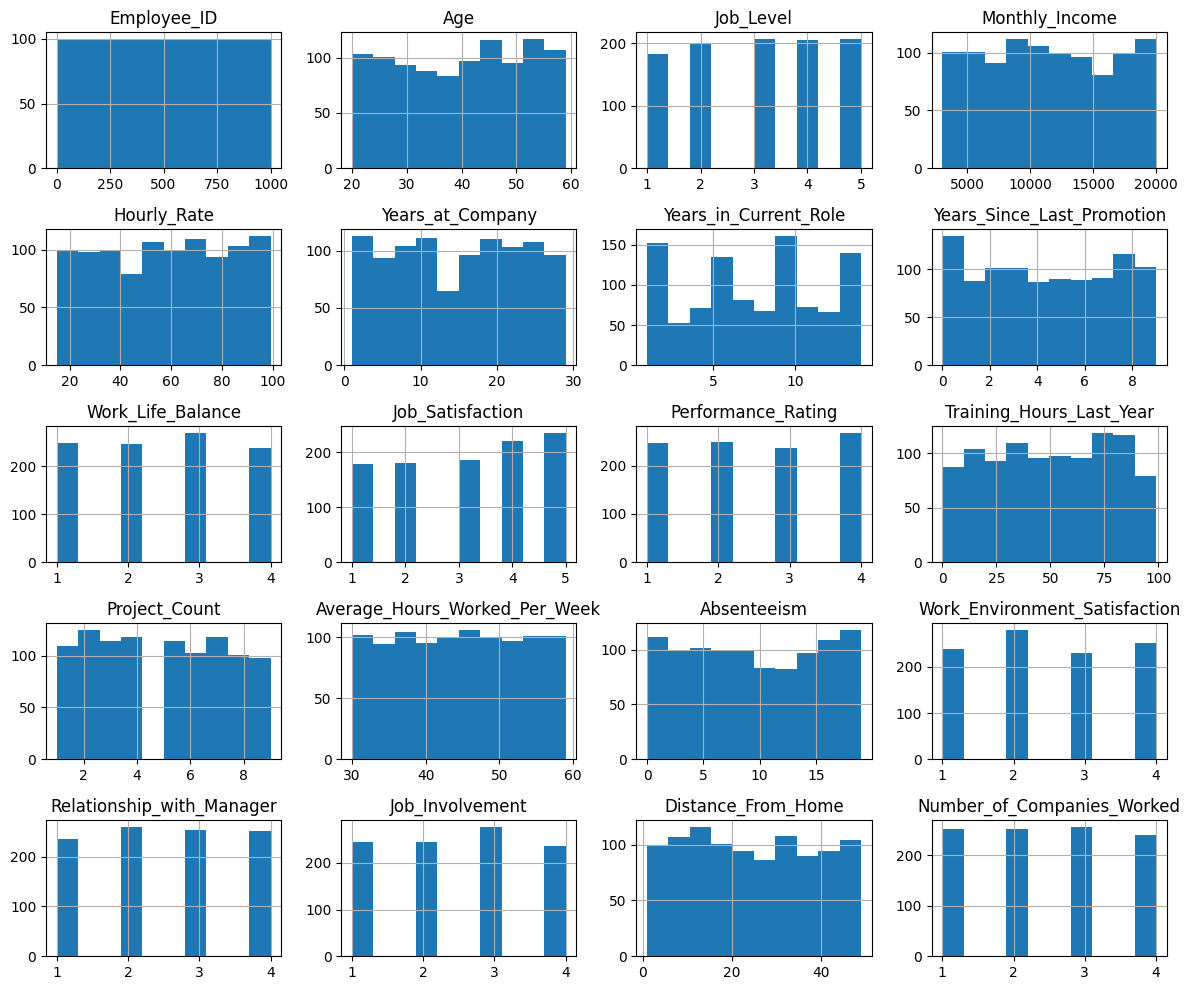

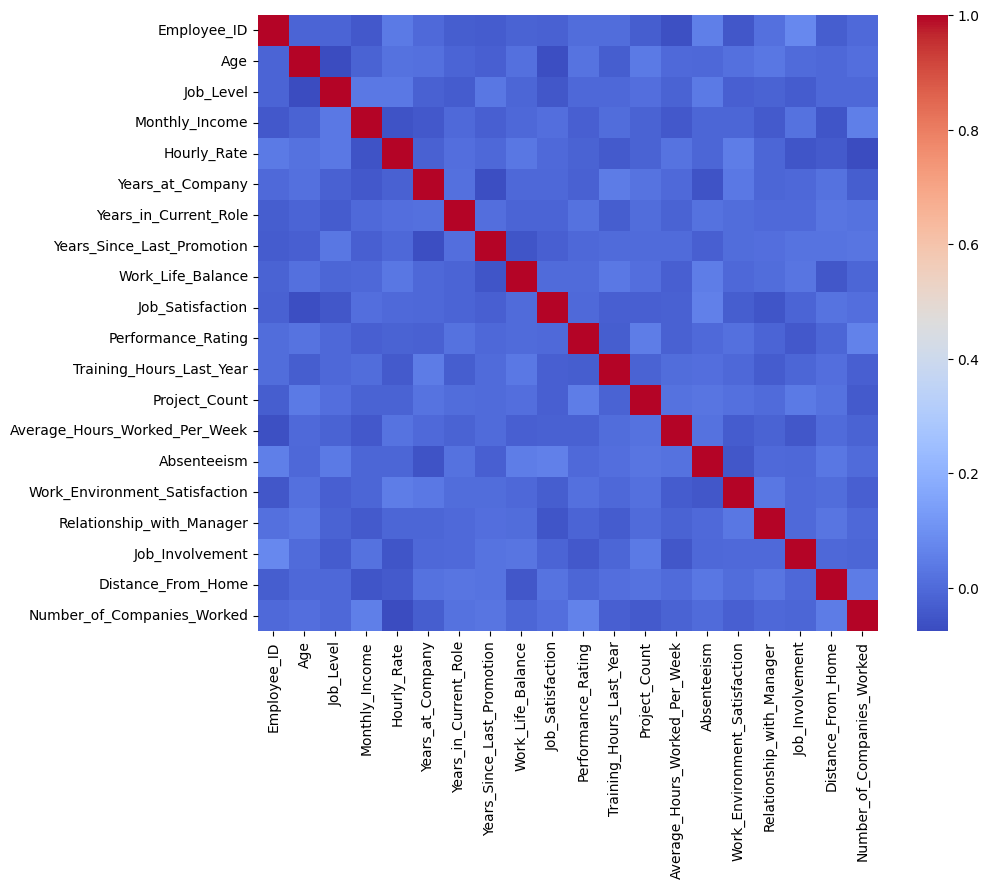

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm')
plt.show()

df.describe()

## Proper Data Splitting

This step splits the dataset into training, validation, and test sets. The split ensures that the model is trained only on training data and evaluated on unseen data, preventing data leakage and ensuring reliable performance evaluation.


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# First split: Train + Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check shapes
print("=== Data Splitting ===")
print(f"Training Set   : {X_train.shape}")
print(f"Validation Set : {X_val.shape}")
print(f"Test Set       : {X_test.shape}")

=== Data Splitting ===
Training Set   : (700, 25)
Validation Set : (150, 25)
Test Set       : (150, 25)


## Encoding Categorical Features

This step converts categorical variables into numerical format using label encoding. The encoder is fitted only on training data and then applied to validation and test sets to prevent data leakage.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Get categorical columns from X_train (correct way)
cat_cols = X_train.select_dtypes(include='object').columns

# Copy datasets
X_train_enc = X_train.copy()
X_val_enc = X_val.copy()
X_test_enc = X_test.copy()

# Encode categorical columns
le = LabelEncoder()

for col in cat_cols:
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_val_enc[col] = le.transform(X_val[col])
    X_test_enc[col] = le.transform(X_test[col])

## Feature Scaling

This step standardizes numerical features using StandardScaler. The scaler is fitted only on training data and applied to validation and test sets to prevent data leakage.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_enc)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)

## Model Training

This step trains a Logistic Regression model using the properly preprocessed training data to establish a baseline performance.


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## Making Predictions

The trained model is used to generate predictions on validation and test datasets for performance evaluation.


In [ ]:
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

## Model Evaluation

This step evaluates model performance using Accuracy, Precision, Recall, and F1-score on validation and test datasets to measure true performance.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Validation Metrics ===")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Precision: {precision_score(y_val, y_val_pred, pos_label='Yes'):.3f}")
print(f"Recall   : {recall_score(y_val, y_val_pred, pos_label='Yes'):.3f}")
print(f"F1 Score : {f1_score(y_val, y_val_pred, pos_label='Yes'):.3f}")

print("\n=== Test Metrics ===")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred, pos_label='Yes'):.3f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, pos_label='Yes'):.3f}")
print(f"F1 Score : {f1_score(y_test, y_test_pred, pos_label='Yes'):.3f}")

=== Validation Metrics ===
Accuracy : 0.813
Precision: 0.000
Recall   : 0.000
F1 Score : 0.000

=== Test Metrics ===
Accuracy : 0.807
Precision: 0.000
Recall   : 0.000
F1 Score : 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

This step visualizes the model’s prediction performance by comparing actual and predicted values, helping to understand classification errors.


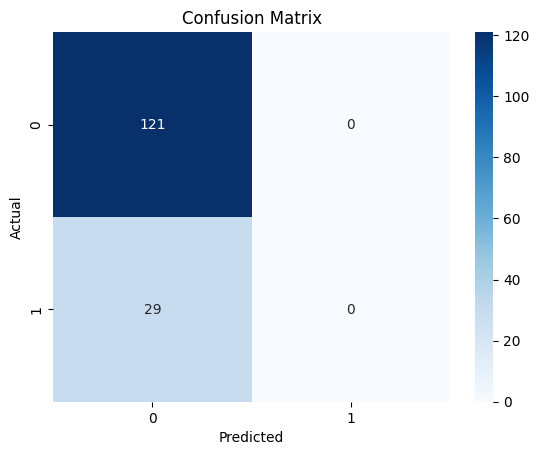

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Performance Visualization

This step visualizes key evaluation metrics to better understand model performance and compare results in later stages.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


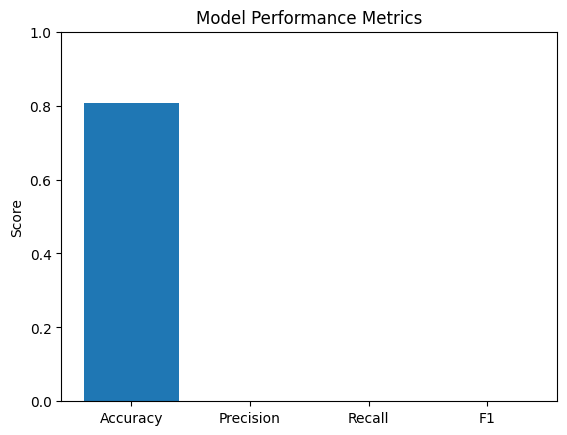

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

values = [
    accuracy_score(y_test, y_test_pred),
    precision_score(y_test, y_test_pred, pos_label='Yes'),
    recall_score(y_test, y_test_pred, pos_label='Yes'),
    f1_score(y_test, y_test_pred, pos_label='Yes')
]

plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

## Validation vs Test Comparison

This step compares model performance on validation and test datasets to check consistency and generalization.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


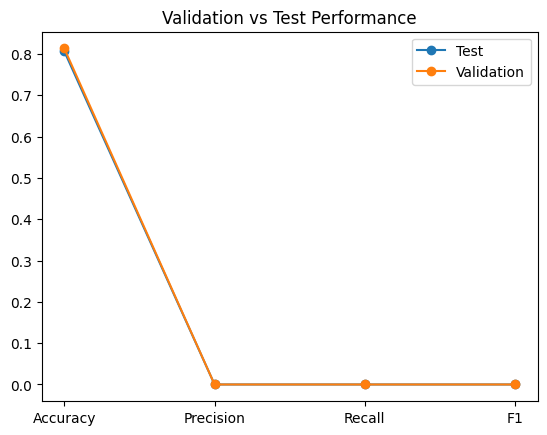

In [ ]:
val_values = [
    accuracy_score(y_val, y_val_pred),
    precision_score(y_val, y_val_pred, pos_label='Yes'),
    recall_score(y_val, y_val_pred, pos_label='Yes'),
    f1_score(y_val, y_val_pred, pos_label='Yes')
]

x = range(len(metrics))

plt.plot(x, values, label='Test', marker='o')
plt.plot(x, val_values, label='Validation', marker='o')

plt.xticks(x, metrics)
plt.title("Validation vs Test Performance")
plt.legend()
plt.show()

## Creating Leaky Dataset

This step intentionally applies encoding and scaling on the entire dataset before splitting, allowing information from validation and test data to leak into the training process.


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Copy full dataset
df_leaky = df.copy()

# Separate features and target
X_leaky = df_leaky.drop('Attrition', axis=1)
y_leaky = df_leaky['Attrition']

# Encode categorical columns (on FULL data ❌)
cat_cols_leaky = X_leaky.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols_leaky:
    X_leaky[col] = le.fit_transform(X_leaky[col])

# Scale FULL data ❌
scaler = StandardScaler()
X_leaky_scaled = scaler.fit_transform(X_leaky)

## Incorrect Data Splitting

This step performs data splitting after preprocessing, which introduces data leakage and results in overly optimistic model performance.


In [ ]:
from sklearn.model_selection import train_test_split

X_train_l, X_temp_l, y_train_l, y_temp_l = train_test_split(
    X_leaky_scaled, y_leaky, test_size=0.3, random_state=42, stratify=y_leaky
)

X_val_l, X_test_l, y_val_l, y_test_l = train_test_split(
    X_temp_l, y_temp_l, test_size=0.5, random_state=42, stratify=y_temp_l
)

## Training on Leaky Data

The model is trained on data that has already been influenced by information from the entire dataset, making evaluation unreliable.


In [ ]:
from sklearn.linear_model import LogisticRegression

model_leaky = LogisticRegression(max_iter=1000)

model_leaky.fit(X_train_l, y_train_l)

LogisticRegression(max_iter=1000)

## Leaky Model Evaluation

This step evaluates the model trained on leaky data, which is expected to show artificially inflated performance compared to the proper pipeline.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_test_pred_l = model_leaky.predict(X_test_l)

print("Leaky Model Performance:")
print("Accuracy:", accuracy_score(y_test_l, y_test_pred_l))
print("Precision:", precision_score(y_test_l, y_test_pred_l, pos_label='Yes'))
print("Recall:", recall_score(y_test_l, y_test_pred_l, pos_label='Yes'))
print("F1 Score:", f1_score(y_test_l, y_test_pred_l, pos_label='Yes'))

Leaky Model Performance:
Accuracy: 0.8066666666666666
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
pd.Series(y_test_pred_l).value_counts()

,count
No,150


## Observation on Leaky Model

The model predicted only the majority class (Attrition = No), resulting in high accuracy but zero precision, recall, and F1-score for the minority class. This demonstrates that accuracy alone can be misleading, especially in imbalanced datasets, and highlights the importance of using multiple evaluation metrics.


## Storing Model Results

This step stores evaluation metrics for both proper and leaky pipelines to enable direct comparison of their performance.


In [ ]:
# Proper model results (from Day 4)
proper_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, pos_label='Yes'),
    "Recall": recall_score(y_test, y_test_pred, pos_label='Yes'),
    "F1 Score": f1_score(y_test, y_test_pred, pos_label='Yes')
}

# Leaky model results (from Day 6)
leaky_results = {
    "Accuracy": accuracy_score(y_test_l, y_test_pred_l),
    "Precision": precision_score(y_test_l, y_test_pred_l, pos_label='Yes', zero_division=0),
    "Recall": recall_score(y_test_l, y_test_pred_l, pos_label='Yes', zero_division=0),
    "F1 Score": f1_score(y_test_l, y_test_pred_l, pos_label='Yes', zero_division=0)
}

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Performance Comparison

This table compares evaluation metrics between the properly trained model and the leaky model to highlight differences in performance.


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Proper Pipeline": proper_results,
    "Leaky Pipeline": leaky_results
})

comparison_df
comparison_df.round(3)

,Proper Pipeline,Leaky Pipeline
Accuracy,0.807,0.807
Precision,0.000,0.000
Recall,0.000,0.000
F1 Score,0.000,0.000


## Comparison Visualization

This visualization highlights differences between proper and leaky pipelines, making it easier to observe how data leakage affects model performance.


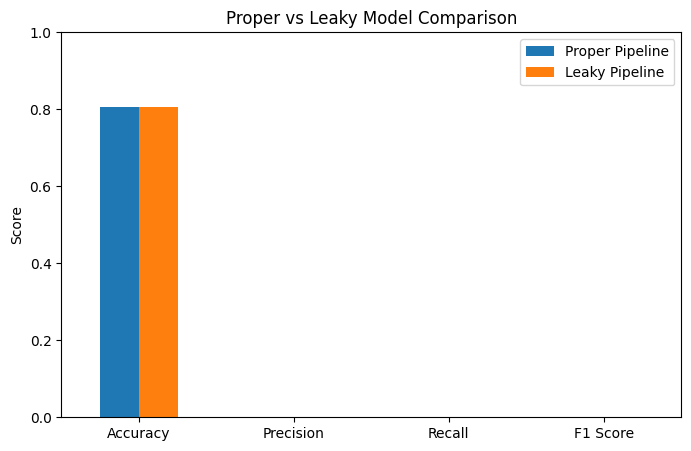

In [ ]:
comparison_df.plot(kind='bar', figsize=(8,5))
plt.title("Proper vs Leaky Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

## Final Analysis

The comparison shows that the leaky pipeline does not provide reliable performance despite preprocessing the full dataset. While accuracy appears relatively high, the model fails to predict the minority class, resulting in poor precision, recall, and F1-score.

This demonstrates that improper data handling can lead to misleading conclusions and that accuracy alone is not sufficient to evaluate model performance. Proper data splitting and evaluation are essential to ensure model reliability in real-world applications.


## Observations

* The proper pipeline provides reliable evaluation by ensuring strict separation between training and test data.
* The leaky pipeline introduces information from the full dataset during preprocessing, making evaluation unreliable.
* The leaky model achieved relatively high accuracy but failed to predict the minority class.
* Precision, recall, and F1-score revealed that the model was not effectively identifying attrition cases.
* This highlights that accuracy alone is not sufficient for evaluating model performance, especially in imbalanced datasets.


## Understanding Data Leakage

Data leakage occurs when information from outside the training dataset is used during model building. In this project, leakage was introduced by applying preprocessing techniques such as encoding and scaling on the entire dataset before splitting.

This allows the model to indirectly access information from validation and test data, leading to misleading performance evaluation. As a result, the model may appear to perform well but fails to generalize to real-world unseen data.

Proper machine learning practice requires that all preprocessing steps be fitted only on training data and then applied to validation and test sets.


## Conclusion

This study demonstrates the impact of data leakage on machine learning model evaluation. The comparison between proper and leaky pipelines shows that improper data handling can lead to misleading performance metrics.

Although the leaky model achieved higher accuracy, it failed to capture meaningful patterns, particularly for the minority class. This highlights the importance of using multiple evaluation metrics and following correct preprocessing practices.

Overall, the project emphasizes that reliable model evaluation depends not only on model selection but also on proper data handling and experimental design.
